# WikiText-2: Tiny Decoder Self-Attention

WikiText-2 next-token training with `Tokenizer(BPE())`, a `Whitespace`
pre-tokenizer, and no documents or references. Model architecture and
smoke-run limits are resolved from `config/config.yml`.

In [1]:
from pathlib import Path
import sys

repo = Path.cwd()
if repo.name == "nb":
    repo = repo.parent
sys.path.insert(0, str(repo / "src"))
sys.path.insert(0, str(repo / "nb"))
sys.path.insert(0, str(repo))

import pra_notebook_utils as pnu

EXPERIMENT_NAME = "td_sa_tiny_wikitext2_smoke"
WRITE_IMAGES_TO_DISK = False

## Runtime And Resolved Experiment

In [2]:
runtime = pnu.configure_notebook(repo=repo, seed=7)
experiment_settings = pnu.load_experiment_settings(runtime, EXPERIMENT_NAME)
{
    "runtime": runtime.as_dict(),
    "experiment": experiment_settings["experiment"],
    "model": experiment_settings["resolved"]["model"],
}

{'runtime': {'repo': 'D:\\git\\rd\\pdattention',
  'seed': 7,
  'device': 'cuda',
  'write_images_to_disk': False,
  'python': '3.10.11',
  'torch_version': '2.12.1+cu126',
  'torch_cuda': '12.6',
  'cuda_available': True,
  'gpu': 'NVIDIA GeForce GTX 950M',
  'compute_capability': (5, 0)},
 'experiment': {'model_name': 'td_sa_tiny',
  'dataset': {'type': 'wikitext',
   'name': 'wikitext-2-raw-v1',
   'vocab_size': 2000,
   'max_train_documents': 256,
   'max_eval_documents': 64,
   'max_train_blocks': 64},
  'train': {'epochs': 1,
   'max_steps': 16,
   'batch_size': 2,
   'learning_rate': 0.0003,
   'max_seq_len': 128}},
 'model': {'d_model': 256,
  'n_heads': 4,
  'n_layers': 4,
  'n_vanilla_layers': 4,
  'n_mixed_layers': 0,
  'max_seq_len': 256,
  'dropout': 0.1,
  'model_variant': 'td_sa'}}

## Train And Evaluate Language Modeling Loss

In [3]:
training_result = pnu.train_wikitext_language_experiment(runtime, EXPERIMENT_NAME)

[config] TrainConfig(experiment_name='td_sa_tiny_wikitext2_steps16_seq128', output_dir='D:\\git\\rd\\pdattention\\out\\notebook_wikitext', seed=7, device='cuda', dtype='float32', epochs=1, max_steps=16, batch_size=2, grad_accum_steps=1, learning_rate=0.0003, weight_decay=0.0, warmup_steps=0, max_grad_norm=1.0, eval_every_steps=16, save_every_steps=16, log_every_steps=1, num_workers=0, pin_memory=False, persistent_workers=False, resume_from=None, use_tensorboard=False, save_metric_plots=False, use_wandb=False, use_clearml=False, mixed_precision=False, early_stopping_patience=None, dataset_stage='wikitext2', data_dir='D:\\git\\rd\\pdattention\\data', max_examples=None, max_seq_len=128, shuffle=True, resolver_config=ResolverServiceConfig(type='in_memory', options={}), cache_config=CacheServiceConfig(type='simple', options={}))


epoch 1/1:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 1/1:   0%|          | 0/32 [00:00<?, ?it/s, step=1, loss=7.76, lr=0.0003, ex/s=4.73, tok/s=606]

epoch 1/1:   3%|▎         | 1/32 [00:00<00:13,  2.33it/s, step=1, loss=7.76, lr=0.0003, ex/s=4.73, tok/s=606]

epoch 1/1:   3%|▎         | 1/32 [00:00<00:13,  2.33it/s, step=2, loss=7.76, lr=0.0003, ex/s=47.3, tok/s=6.05e+3]

...

[val step=16] val_loss=7.1735 loss=7.1735 perplexity=1304.3824 token_accuracy=0.0263 tokens=9984.0000 tokens_per_second=33450.0825 latency=0.2985 gpu_memory_allocated=66.4619


epoch 1/1:  41%|████      | 13/32 [00:01<00:01, 17.22it/s, step=16, loss=7.09, lr=0.0003, ex/s=44.2, tok/s=5.66e+3, val=7.17]

epoch 1/1:  47%|████▋     | 15/32 [00:01<00:02,  8.33it/s, step=16, loss=7.09, lr=0.0003, ex/s=44.2, tok/s=5.66e+3, val=7.17]

[train_epoch step=1] train_loss=7.4425 perplexity=1706.9607 learning_rate=0.0003 grad_norm=1.3554 examples_per_second=17.7557 tokens_per_second=2272.7299 gpu_memory_allocated=64.5029 epoch=1.0000 batches=16.0000 batch_step=16.0000 optimizer_step=16.0000 examples=32.0000 tokens=4096.0000 duration_seconds=1.8022
[val_epoch step=1] val_loss=7.1735 loss=7.1735 perplexity=1304.3824 token_accuracy=0.0263 tokens=9984.0000 tokens_per_second=33450.0825 latency=0.2985 gpu_memory_allocated=66.4619 epoch=1.0000 optimizer_step=16.0000


[test step=16] test_loss=7.1148 loss=7.1148 perplexity=1229.9804 token_accuracy=0.0300 tokens=8832.0000 tokens_per_second=36740.6791 latency=0.2404 gpu_memory_allocated=65.4824


In [4]:
run_summary = pnu.summarize_workload(training_result)
run_summary

{'dataset_stage': 'wikitext2',
 'size': 64,
 'parameters': 4216320,
 'epochs': 1,
 'optimizer_steps': 16,
 'batch_steps': 16,
 'train_loss': 7.44246968626976,
 'validation_loss': 7.1734849856450005,
 'test_loss': 7.11475348127061,
 'test_perplexity': 1229.9803606288933,
 'test_token_accuracy': 0.030004528985507248,
 'test_answer_accuracy': None,
 'test_reference_accuracy': None}

## Batch-Wise And Epoch-Wise Progress

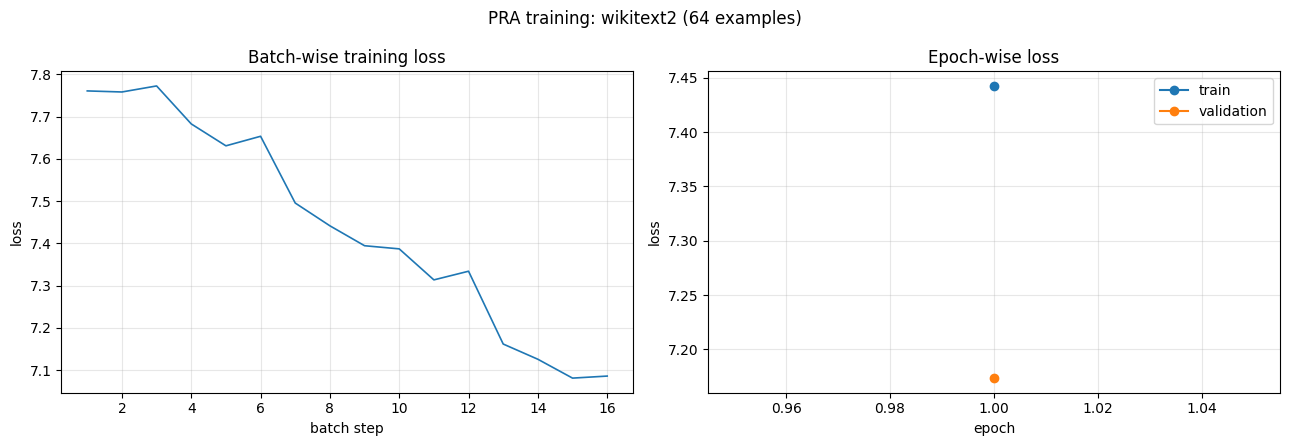

{'train_batches': 16,
 'train_epochs': 1,
 'validation_epochs': 1,
 'metrics_path': WindowsPath('D:/git/rd/pdattention/out/notebook_wikitext/td_sa_tiny_wikitext2_steps16_seq128/metrics.json'),
 'image_path': None}

In [5]:
progress = pnu.plot_training_progress(training_result, write_to_disk=False)
progress

## HTML Experiment Report

In [6]:
report_path = pnu.generate_html_report(
    training_result,
    runtime=runtime,
    dataset_details=training_result["loader_summary"],
    model_name=training_result["model_name"],
    qualifiers=(f"steps{training_result['global_step']}", f"seq{training_result['policy'].max_seq_len}"),
)
report_path

wrote HTML report: D:\git\rd\pdattention\out\reports\td_sa_tiny_wikitext2_steps16_seq128\index.html


WindowsPath('D:/git/rd/pdattention/out/reports/td_sa_tiny_wikitext2_steps16_seq128/index.html')